<a href="https://colab.research.google.com/github/SanaAlotaibi/DataScienceProject/blob/main/IT362_Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


In [9]:
df = pd.read_csv("CleanedDataset.csv")

print(" Dataset Loaded Successfully!")
df.head()


 Dataset Loaded Successfully!


,name,owner,url,description,stars,forks,created_at,pushed_at,primary_language,all_languages_bytes,topics,contributors_count
0,DeepSpeed,deepspeedai,https://github.com/deepspeedai/DeepSpeed,DeepSpeed is a deep learning optimization libr...,40213,4564,2020-01-23T18:35:18Z,2025-09-25T00:42:02Z,Python,"{'Python': 5912469, 'C++': 1505585, 'Cuda': 71...","deep-learning, pytorch, gpu, machine-learning,...",1
1,EasyOCR,JaidedAI,https://github.com/JaidedAI/EasyOCR,Ready-to-use OCR with 80+ supported languages ...,28016,3470,2020-03-14T11:46:39Z,2024-09-24T11:24:36Z,Python,"{'Python': 633819, 'C++': 112732, 'Cuda': 5825...","ocr, deep-learning, crnn, pytorch, lstm, machi...",1
2,fastbook,fastai,https://github.com/fastai/fastbook,"The fastai book, published as Jupyter Notebooks",23807,9161,2020-02-28T19:26:47Z,2024-08-16T14:38:24Z,Jupyter Notebook,"{'Jupyter Notebook': 8892620, 'Python': 5190}","notebooks, fastai, deep-learning, machine-lear...",1
3,serve,jina-ai,https://github.com/jina-ai/serve,☁️ Build multimodal AI applications with cloud...,21746,2236,2020-02-13T17:04:44Z,2025-03-24T13:59:54Z,Python,"{'Python': 2806034, 'Go': 46933, 'Shell': 2394...","neural-search, cloud-native, deep-learning, ma...",1
4,datasets,huggingface,https://github.com/huggingface/datasets,🤗 The largest hub of ready-to-use datasets for...,20687,2953,2020-03-26T09:23:22Z,2025-09-24T20:54:18Z,Python,"{'Python': 3005121, 'Makefile': 465}","nlp, datasets, pytorch, tensorflow, pandas, nu...",1


In [10]:
import pandas as pd
df = pd.read_csv("CleanedDataset.csv")
print(df.shape)
print(df.columns.tolist())
df.head()


(5109, 12)
['name', 'owner', 'url', 'description', 'stars', 'forks', 'created_at', 'pushed_at', 'primary_language', 'all_languages_bytes', 'topics', 'contributors_count']


,name,owner,url,description,stars,forks,created_at,pushed_at,primary_language,all_languages_bytes,topics,contributors_count
0,DeepSpeed,deepspeedai,https://github.com/deepspeedai/DeepSpeed,DeepSpeed is a deep learning optimization libr...,40213,4564,2020-01-23T18:35:18Z,2025-09-25T00:42:02Z,Python,"{'Python': 5912469, 'C++': 1505585, 'Cuda': 71...","deep-learning, pytorch, gpu, machine-learning,...",1
1,EasyOCR,JaidedAI,https://github.com/JaidedAI/EasyOCR,Ready-to-use OCR with 80+ supported languages ...,28016,3470,2020-03-14T11:46:39Z,2024-09-24T11:24:36Z,Python,"{'Python': 633819, 'C++': 112732, 'Cuda': 5825...","ocr, deep-learning, crnn, pytorch, lstm, machi...",1
2,fastbook,fastai,https://github.com/fastai/fastbook,"The fastai book, published as Jupyter Notebooks",23807,9161,2020-02-28T19:26:47Z,2024-08-16T14:38:24Z,Jupyter Notebook,"{'Jupyter Notebook': 8892620, 'Python': 5190}","notebooks, fastai, deep-learning, machine-lear...",1
3,serve,jina-ai,https://github.com/jina-ai/serve,☁️ Build multimodal AI applications with cloud...,21746,2236,2020-02-13T17:04:44Z,2025-03-24T13:59:54Z,Python,"{'Python': 2806034, 'Go': 46933, 'Shell': 2394...","neural-search, cloud-native, deep-learning, ma...",1
4,datasets,huggingface,https://github.com/huggingface/datasets,🤗 The largest hub of ready-to-use datasets for...,20687,2953,2020-03-26T09:23:22Z,2025-09-24T20:54:18Z,Python,"{'Python': 3005121, 'Makefile': 465}","nlp, datasets, pytorch, tensorflow, pandas, nu...",1


In [11]:
import re

def normalize(col):
    col = col.strip().lower()
    col = re.sub(r'[\s\-]+', '_', col)      # مسافات/شرطات -> _
    col = re.sub(r'[^0-9a-zA-Z_]+', '', col)
    return col

df.columns = [normalize(c) for c in df.columns]
print(df.columns.tolist())


['name', 'owner', 'url', 'description', 'stars', 'forks', 'created_at', 'pushed_at', 'primary_language', 'all_languages_bytes', 'topics', 'contributors_count']


In [12]:
# دوال مساعدة لاختيار أول عمود يطابق أي مرشح
def pick(colnames, candidates):
    for c in colnames:
        for cand in candidates:
            if cand in c:
                return c
    return None

cols = df.columns.tolist()

stars_col  = pick(cols, ["stargazers_count","stars","stargazers"])
forks_col  = pick(cols, ["forks_count","forks"])
lang_col   = pick(cols, ["primary_language","language","lang"])
year_col   = pick(cols, ["created_year","year"])  # قد ما يكون موجود

created_at_col = pick(cols, ["created_at","created_date","created"])  # بديل لاستخراج السنة إن ما وُجد year

print("stars_col :", stars_col)
print("forks_col :", forks_col)
print("lang_col  :", lang_col)
print("year_col  :", year_col)
print("created_at_col :", created_at_col)


stars_col : stars
forks_col : forks
lang_col  : primary_language
year_col  : None
created_at_col : created_at


In [13]:
import numpy as np

if (year_col is None) and (created_at_col is not None):
    df['created_year'] = pd.to_datetime(df[created_at_col], errors='coerce').dt.year
    year_col = 'created_year'

# تحويل أعمدة النجوم/الفورك لأرقام لو كانت نصوص
for c in [stars_col, forks_col]:
    df[c] = pd.to_numeric(df[c], errors='coerce')


In [14]:
required = [stars_col, forks_col, year_col, lang_col]
if any(x is None for x in required):
    missing = [n for n,x in zip(["stars","forks","year","language"], required) if x is None]
    raise ValueError(f"Couldn't find needed columns: {missing}. Please show df.columns so we map them manually.")

# تخلص من الصفوف الناقصة
use_df = df[[stars_col, forks_col, year_col, lang_col]].dropna().copy()
use_df.head()


,stars,forks,created_year,primary_language
0,40213.0,4564.0,2020.0,Python
1,28016.0,3470.0,2020.0,Python
2,23807.0,9161.0,2020.0,Jupyter Notebook
3,21746.0,2236.0,2020.0,Python
4,20687.0,2953.0,2020.0,Python


In [15]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Encode language
enc = LabelEncoder()
use_df['language_encoded'] = enc.fit_transform(use_df[lang_col].fillna('Unknown').astype(str))

# Features + scaling
X = use_df[[stars_col, forks_col, year_col, 'language_encoded']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


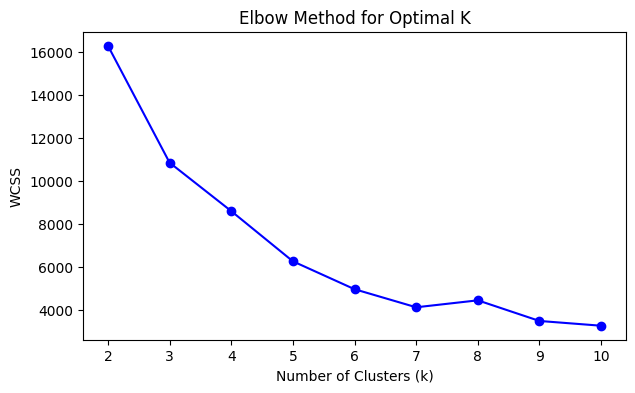

In [16]:
wcss = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K, wcss, 'bo-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()


Silhouette (KMeans): 0.383


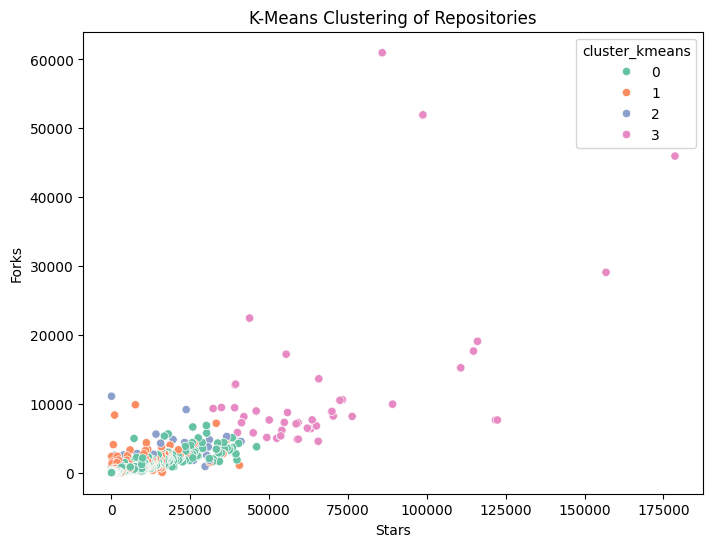

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)
use_df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

print("Silhouette (KMeans):", round(silhouette_score(X_scaled, use_df['cluster_kmeans']), 3))

plt.figure(figsize=(8,6))
sns.scatterplot(x=use_df[stars_col], y=use_df[forks_col], hue=use_df['cluster_kmeans'], palette='Set2')
plt.title('K-Means Clustering of Repositories')
plt.xlabel('Stars'); plt.ylabel('Forks')
plt.show()


Clusters (valid only): 1 | Noise ratio: 1.10%
 DBSCAN returned <2 clusters among non-noise points — tune eps/min_samples.


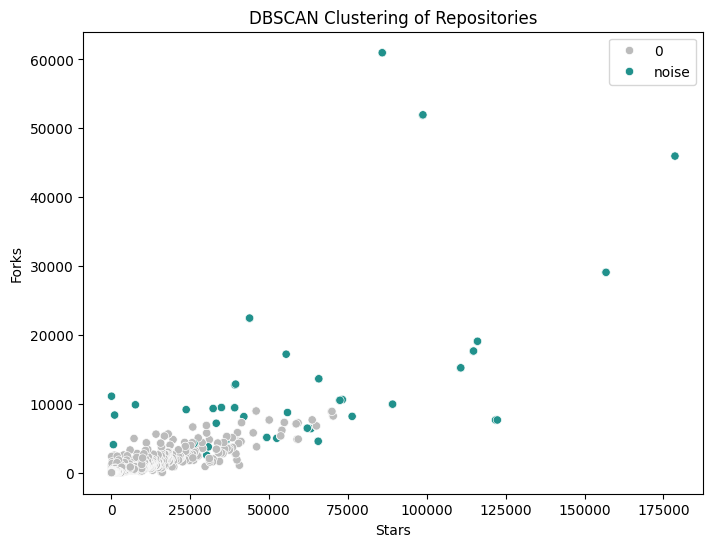

In [18]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

db = DBSCAN(eps=1.2, min_samples=8)
use_df['cluster_dbscan'] = db.fit_predict(X_scaled)

valid_mask = use_df['cluster_dbscan'] != -1
valid_labels = use_df.loc[valid_mask, 'cluster_dbscan']
n_clusters_valid = valid_labels.nunique()
noise_ratio = 1.0 - valid_mask.mean()

print(f"Clusters (valid only): {n_clusters_valid} | Noise ratio: {noise_ratio:.2%}")

if (valid_mask.sum() > 0) and (n_clusters_valid >= 2):
    sil_db = silhouette_score(X_scaled[valid_mask], valid_labels)
    print(f"Silhouette (DBSCAN): {sil_db:.3f}")
else:
    print(" DBSCAN returned <2 clusters among non-noise points — tune eps/min_samples.")

plt.figure(figsize=(8,6))
palette = sns.color_palette("viridis", max(n_clusters_valid, 1))
sns.scatterplot(
    x=use_df[stars_col], y=use_df[forks_col],
    hue=np.where(use_df['cluster_dbscan'] == -1, 'noise', use_df['cluster_dbscan'].astype(str)),
    palette=["#bbbbbb"] + palette if n_clusters_valid > 0 else ["#bbbbbb"],
    legend='full'
)
plt.title('DBSCAN Clustering of Repositories')
plt.xlabel('Stars'); plt.ylabel('Forks')
plt.show()


Regression

Top Secondary Languages Used Alongside Python:
secondary_lang
Shell               350
Jupyter Notebook    241
Dockerfile          149
TypeScript          123
Makefile            123
JavaScript          120
HTML                 97
C++                  54
Cuda                 35
CSS                  27
Name: count, dtype: int64


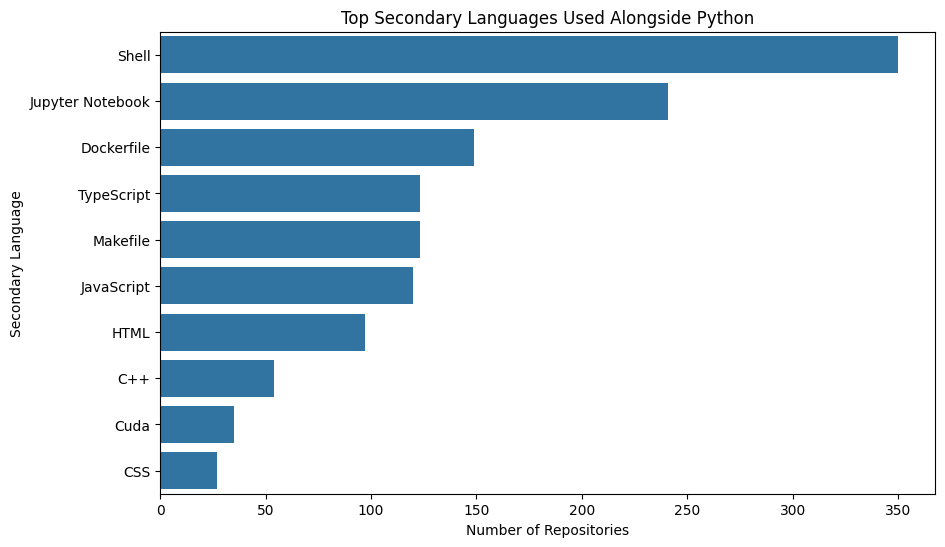


Baseline Model
MSE: 23.82
R²: -0.0

Linear Regression
MSE: 15.78
R²: 0.337

Decision Tree
MSE: 3.7
R²: 0.845

Random Forest
MSE: 2.11
R²: 0.912

Model Comparison:
               Model        MSE            R²
0           Baseline  23.820455 -4.987631e-07
1  Linear Regression  15.783159  3.374112e-01
2      Decision Tree   3.698229  8.447456e-01
3      Random Forest   2.106668  9.115605e-01


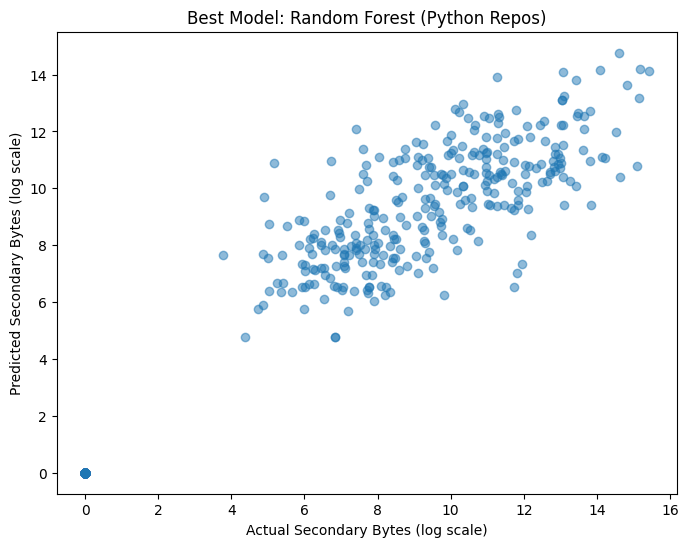

In [28]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


def parse_lang_bytes(x):
    try:
        return ast.literal_eval(x)
    except:
        return {}

df['all_languages_bytes_dict'] = df['all_languages_bytes'].apply(parse_lang_bytes)


# Keep only Python repos
df_python = df[df['primary_language'] == 'Python'].copy()


def get_secondary_lang(d):
    if not d:
        return (None, 0)

    d = {k: v for k, v in d.items() if k != 'Python'}

    if not d:
        return (None, 0)

    sorted_langs = sorted(d.items(), key=lambda item: item[1], reverse=True)
    return sorted_langs[0]


df_python['secondary_lang'], df_python['secondary_bytes'] = zip(
    *df_python['all_languages_bytes_dict'].apply(get_secondary_lang)
)


# Top 10 secondary languages
top_secondary = df_python['secondary_lang'].value_counts().head(10)

print("Top Secondary Languages Used Alongside Python:")
print(top_secondary)

plt.figure(figsize=(10,6))
sns.barplot(x=top_secondary.values, y=top_secondary.index)
plt.title("Top Secondary Languages Used Alongside Python")
plt.xlabel("Number of Repositories")
plt.ylabel("Secondary Language")
plt.show()

df_reg = df_python.dropna(subset=[
    'secondary_bytes', 'stars', 'forks', 'contributors_count'
])

df_reg['contributors_count'] = pd.to_numeric(df_reg['contributors_count'], errors='coerce')
df_reg = df_reg.dropna(subset=['contributors_count'])

df_reg['secondary_lang_encoded'] = LabelEncoder().fit_transform(
    df_reg['secondary_lang'].fillna('Unknown')
)

X = df_reg[['stars', 'forks', 'contributors_count', 'secondary_lang_encoded']]
# Log-transform target (improves model accuracy)
y = np.log1p(df_reg['secondary_bytes'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Baseline Model
baseline_pred = [y_train.mean()] * len(y_test)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("\nBaseline Model")
print("MSE:", round(baseline_mse, 2))
print("R²:", round(baseline_r2, 3))


# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("\nLinear Regression")
print("MSE:", round(lr_mse, 2))
print("R²:", round(lr_r2, 3))


# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("\nDecision Tree")
print("MSE:", round(dt_mse, 2))
print("R²:", round(dt_r2, 3))


# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest")
print("MSE:", round(rf_mse, 2))
print("R²:", round(rf_r2, 3))

results = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE': [baseline_mse, lr_mse, dt_mse, rf_mse],
    'R²': [baseline_r2, lr_r2, dt_r2, rf_r2]
})

print("\nModel Comparison:")
print(results)


# Scatter plot of best model
best_pred = rf_pred

plt.figure(figsize=(8,6))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.xlabel("Actual Secondary Bytes (log scale)")
plt.ylabel("Predicted Secondary Bytes (log scale)")
plt.title("Best Model: Random Forest (Python Repos)")
plt.show()
